<a href="https://colab.research.google.com/github/Lessio2006/UEBA_proj/blob/develop/UEBA_research_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[Dataset](https://drive.google.com/file/d/1yAQ_0NQKeaXIbFQaJTBVwXGA_zlCrjKY/view?usp=sharing)

In [1]:
!gdown --id 1yAQ_0NQKeaXIbFQaJTBVwXGA_zlCrjKY -O 'system.csv'

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1yAQ_0NQKeaXIbFQaJTBVwXGA_zlCrjKY
To: /content/system.csv
100% 655k/655k [00:00<00:00, 106MB/s]


In [2]:
import pandas as pd
import numpy as np
import torch.nn as nn
import torch
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm_notebook
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv('/content/system.csv', encoding='utf-8')
df.head()

,timestamp,hour_sin,hour_cos,weekday_sin,weekday_cos,cpu_mean,cpu_max,ram_mean,ram_max,swap_mean,...,listening_count_mean,time_wait_count_mean,new_connection_count,closed_connection_count,unique_remote_host_count,new_remote_host_count,unique_remote_port_count,public_connection_count_mean,private_connection_count_mean,outbound_inbound_ratio
0,2026-07-17T03:50:35Z,0.975740,-0.218933,-0.433884,-0.900969,14.800000,32.8,68.033333,69.4,1.500000,...,38.000000,18.333333,33,33,33,0,25,75.333333,28.000000,0.586664
1,2026-07-17T03:50:50Z,0.975500,-0.219999,-0.433884,-0.900969,15.700000,18.1,57.066667,65.8,1.500000,...,34.666667,47.666667,112,48,42,10,25,115.000000,22.666667,0.128680
2,2026-07-17T03:51:05Z,0.975259,-0.221066,-0.433884,-0.900969,5.866667,7.1,52.366667,52.4,1.500000,...,33.000000,81.333333,16,38,43,2,17,154.666667,20.000000,2.222904
3,2026-07-17T03:51:20Z,0.975017,-0.222130,-0.433884,-0.900969,9.266667,14.2,52.966667,53.5,1.500000,...,33.000000,60.666667,106,58,56,16,17,166.333333,16.000000,0.203507
4,2026-07-17T03:51:35Z,0.974774,-0.223195,-0.433884,-0.900969,12.433333,17.9,53.733333,54.0,0.833333,...,33.000000,63.000000,39,24,60,7,14,200.333333,14.000000,0.837821


In [4]:
# отсортируем датасет по времени
df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True
)

df = (
    df
    .sort_values("timestamp")
    .reset_index(drop=True)
)

In [5]:
X = df.drop(columns=["timestamp"])

n = len(X)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end].copy()
X_val = X.iloc[train_end:val_end].copy()
X_test = X.iloc[val_end:].copy()

drop_cols = ['weekday_sin', 'weekday_cos']
X_train = X_train.drop(columns=drop_cols)
X_val = X_val.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [6]:
skewness = X.skew()

kurtosis = X.kurt()

print("\nSkewness of numerical features:\n", skewness)
print("\nKurtosis of numerical features:\n", kurtosis)


Skewness of numerical features:
 hour_sin                          0.372266
hour_cos                          0.815205
weekday_sin                       0.000000
weekday_cos                       0.000000
cpu_mean                          1.451910
cpu_max                           1.442113
ram_mean                          0.502959
ram_max                           0.529412
swap_mean                         1.909913
process_count_mean                0.015753
new_process_count                 5.112351
disk_read_bytes                  23.296445
disk_write_bytes                 19.314753
disk_read_ops                    18.868983
disk_write_ops                   27.857684
net_sent_bytes                   18.553651
net_recv_bytes                   10.163227
net_sent_packets                  9.535067
net_recv_packets                  9.684023
tcp_connection_count_mean         4.080443
udp_endpoint_count_mean           0.622830
established_count_mean            4.574142
listening_count_mean

4й стандартный момент определяет тяжесть хвостов

---
Формула 4го стандартного момента:
*  $\alpha_4 = \frac{\mu_4}{\sigma^4} = E\left[\left(\frac{X - \mu}{\sigma}\right)^4\right] = \frac{E[(X - \mu)^4]}{(E[(X - \mu)^2])^2}
$


In [7]:
LOG_COLUMNS = [
    "new_process_count",
    "disk_read_bytes",
    "disk_write_bytes",
    "disk_read_ops",
    "disk_write_ops",
    "net_sent_bytes",
    "net_recv_bytes",
    "net_sent_packets",
    "net_recv_packets",
    "tcp_connection_count_mean",
    "established_count_mean",
    "time_wait_count_mean",
    "new_connection_count",
    "closed_connection_count",
    "unique_remote_host_count",
    "new_remote_host_count",
    "public_connection_count_mean",
    "private_connection_count_mean",
]

for col in LOG_COLUMNS:
    X_train[col] = np.log1p(X_train[col])
    X_val[col] = np.log1p(X_val[col])
    X_test[col] = np.log1p(X_test[col])

In [8]:
scaler = StandardScaler()

non_scaled_cols = ['hour_sin', 'hour_cos']

X_train_to_scale = X_train.drop(columns=non_scaled_cols)
X_train_non_scaled = X_train[non_scaled_cols]

X_val_to_scale = X_val.drop(columns=non_scaled_cols)
X_val_non_scaled = X_val[non_scaled_cols]

X_test_to_scale = X_test.drop(columns=non_scaled_cols)
X_test_non_scaled = X_test[non_scaled_cols]

X_train_scaled_part = scaler.fit_transform(X_train_to_scale)
X_val_scaled_part = scaler.transform(X_val_to_scale)
X_test_scaled_part = scaler.transform(X_test_to_scale)

X_train_scaled_df = pd.DataFrame(X_train_scaled_part, columns=X_train_to_scale.columns, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled_part, columns=X_val_to_scale.columns, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled_part, columns=X_test_to_scale.columns, index=X_test.index)

X_train_scaled = pd.concat([X_train_scaled_df, X_train_non_scaled], axis=1).to_numpy()
X_val_scaled = pd.concat([X_val_scaled_df, X_val_non_scaled], axis=1).to_numpy()
X_test_scaled = pd.concat([X_test_scaled_df, X_test_non_scaled], axis=1).to_numpy()

In [9]:
SEED = 42

torch.manual_seed(SEED)

# CUDA (GPU)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# NumPy
np.random.seed(SEED)

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("CUDA is available! Using GPU.")
else:
    device = torch.device("cpu")
    print("CUDA is not available. Using CPU.")

CUDA is available! Using GPU.


In [11]:
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

In [12]:
train_loader = DataLoader(
    TensorDataset(X_train_tensor),
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    TensorDataset(X_val_tensor),
    batch_size=64,
    shuffle=False
)

# Model

Reparameterezation trick нужен для того, чтобы мы могли считать гралиенты при обучении, понятно что есои в нашей цепочки будет слчайное сэмплирование из PDF, то backprop мы не сомжем использовать.


---
Формула reparameterezation trick:
*  $z = \mu + \sigma \odot \epsilon, \quad \text{где } \epsilon \sim \mathcal{N}(0, 1)$

Формула перехода от $log(Var)$ к $\sigma$:
*  $\sigma = \sqrt{\sigma^2} = \sqrt{\exp(\log(\sigma^2))} = \exp\left(\frac{1}{2} \log(\sigma^2)\right)
$



In [13]:
# input vector -> mlp -> mean, std -> reparam trick -> output clf
class VariationalAE(nn.Module):
  def __init__(self, input_dim=30, hidden_dim=60, latent_dim=6):
    super().__init__()

    self.encoder = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim // 2),
        nn.ReLU(),
        nn.Linear(hidden_dim // 2, hidden_dim // 4),
        nn.ReLU()
    )

    self.fc_mu = nn.Linear(hidden_dim // 4, latent_dim)
    self.fc_log_var = nn.Linear(hidden_dim // 4, latent_dim)

    self.decoder = nn.Sequential(
        nn.Linear(latent_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, input_dim),  # Output layer, reconstructing input_dim features

    )

    self.input_dim = input_dim
    self.hidden_dim = hidden_dim
    self.latent_dim = latent_dim


  def reparameterize(self, mu, log_var):
    """
    :param mu: mean from the encoder's latent space
    :param log_var: log variance from the encoder's latent space
    :return: A sample from the latent distribution
    """
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    sample = mu + (eps * std)
    return sample


  def encode(self, x):
    h = self.encoder(x) # Pass input through the sequential encoder layers
    mu = self.fc_mu(h)
    log_var = self.fc_log_var(h)
    return mu, log_var

  def decode(self, z):
    reconstruction = self.decoder(z) # Pass latent sample through the sequential decoder layers
    return reconstruction

  def forward(self, x):
    mu, log_var = self.encode(x)
    z = self.reparameterize(mu, log_var)
    reconstruction = self.decode(z)    # Decode the latent sample to reconstruct the input
    return reconstruction, mu, log_var


# Loss

In [14]:
def elbo_loss(reconstruction, x, mu, log_var, beta=0.006):
    recon_loss = F.mse_loss(
        reconstruction,
        x,
        reduction="mean"
    )

    kl_loss = -0.5 * torch.mean(
        torch.sum(
            1
            + log_var
            - mu.pow(2)
            - log_var.exp(),
            dim=1
        )
    )

    total_loss = (recon_loss + beta * kl_loss)

    return (
        total_loss,
        recon_loss,
        kl_loss
    )

# Train/test loops

In [15]:
def fit_one_epoch(model, dataloader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0
    running_recon_loss = 0.0
    running_kl_loss = 0.0

    for i, data in enumerate(dataloader):
        inputs = data[0].to(device)

        optimizer.zero_grad()
        reconstruction, mu, log_var = model(inputs)
        total_loss, recon_loss, kl_loss = loss_fn(reconstruction, inputs, mu, log_var)

        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        running_recon_loss += recon_loss.item()
        running_kl_loss += kl_loss.item()

    avg_total_loss = running_loss / len(dataloader)
    avg_recon_loss = running_recon_loss / len(dataloader)
    avg_kl_loss = running_kl_loss / len(dataloader)

    return avg_total_loss, avg_recon_loss, avg_kl_loss

In [16]:
def eval_one_epoch(model, dataloader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    running_recon_loss = 0.0
    running_kl_loss = 0.0

    with torch.no_grad():
        for i, data in enumerate(dataloader):
            inputs = data[0].to(device)

            reconstruction, mu, log_var = model(inputs)
            total_loss, recon_loss, kl_loss = loss_fn(reconstruction, inputs, mu, log_var)

            running_loss += total_loss.item()
            running_recon_loss += recon_loss.item()
            running_kl_loss += kl_loss.item()

    avg_total_loss = running_loss / len(dataloader)
    avg_recon_loss = running_recon_loss / len(dataloader)
    avg_kl_loss = running_kl_loss / len(dataloader)

    return avg_total_loss, avg_recon_loss, avg_kl_loss

In [17]:
def train(model, train_loader, val_loader, optimizer, loss_fn, device, epochs):
    print(f"Training on {device}")

    train_total_losses = []
    val_total_losses = []
    train_recon_losses = []
    val_recon_losses = []
    train_kl_losses = []
    val_kl_losses = []

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # Train
        train_total_loss, train_recon_loss, train_kl_loss = fit_one_epoch(
            model,
            train_loader,
            optimizer,
            loss_fn,
            device
        )
        train_total_losses.append(train_total_loss)
        train_recon_losses.append(train_recon_loss)
        train_kl_losses.append(train_kl_loss)

        # Validation
        val_total_loss, val_recon_loss, val_kl_loss = eval_one_epoch(
            model,
            val_loader,
            loss_fn,
            device
        )
        val_total_losses.append(val_total_loss)
        val_recon_losses.append(val_recon_loss)
        val_kl_losses.append(val_kl_loss)

        print(f"Train Loss: {train_total_loss:.4f} (Recon: {train_recon_loss:.4f}, KL: {train_kl_loss:.4f})")
        print(f"Val Loss:   {val_total_loss:.4f} (Recon: {val_recon_loss:.4f}, KL: {val_kl_loss:.4f})")

    print("Training complete!")
    return train_total_losses, val_total_losses, train_recon_losses, val_recon_losses, train_kl_losses, val_kl_losses

In [18]:
input_dim = X_train_tensor.shape[1]

vae_model = VariationalAE(input_dim=input_dim, hidden_dim=60, latent_dim=6).to(device)
optimizer = torch.optim.Adam(vae_model.parameters(), lr=1e-3)
epochs = 150

train_total_losses, val_total_losses, train_recon_losses, val_recon_losses, train_kl_losses, val_kl_losses = train(
    vae_model,
    train_loader,
    val_loader,
    optimizer,
    elbo_loss,
    device,
    epochs
)

Training on cuda
Epoch 1/150
Train Loss: 0.9568 (Recon: 0.9551, KL: 0.2803)
Val Loss:   1.6477 (Recon: 1.6433, KL: 0.7236)
Epoch 2/150
Train Loss: 0.7089 (Recon: 0.6814, KL: 4.5764)
Val Loss:   1.3891 (Recon: 1.3628, KL: 4.3827)
Epoch 3/150
Train Loss: 0.6044 (Recon: 0.5768, KL: 4.6072)
Val Loss:   1.3369 (Recon: 1.3116, KL: 4.2186)
Epoch 4/150
Train Loss: 0.5897 (Recon: 0.5611, KL: 4.7690)
Val Loss:   1.3049 (Recon: 1.2781, KL: 4.4629)
Epoch 5/150
Train Loss: 0.5534 (Recon: 0.5221, KL: 5.2261)
Val Loss:   1.1025 (Recon: 1.0673, KL: 5.8791)
Epoch 6/150
Train Loss: 0.4874 (Recon: 0.4492, KL: 6.3562)
Val Loss:   0.9247 (Recon: 0.8705, KL: 9.0250)
Epoch 7/150
Train Loss: 0.4611 (Recon: 0.4242, KL: 6.1471)
Val Loss:   0.8900 (Recon: 0.8330, KL: 9.4885)
Epoch 8/150
Train Loss: 0.4480 (Recon: 0.4115, KL: 6.0750)
Val Loss:   0.8840 (Recon: 0.8274, KL: 9.4407)
Epoch 9/150
Train Loss: 0.4359 (Recon: 0.3982, KL: 6.2795)
Val Loss:   0.8759 (Recon: 0.8185, KL: 9.5607)
Epoch 10/150
Train Loss: 0.41

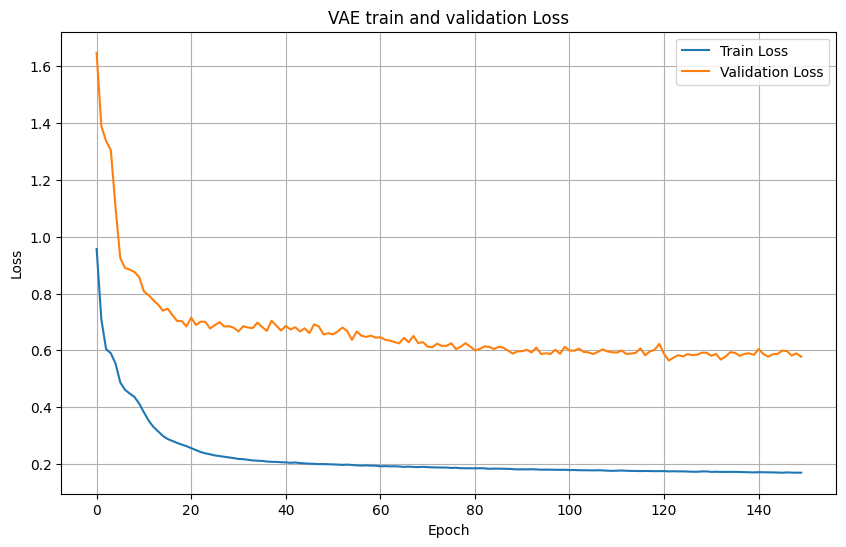

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_total_losses, label='Train Loss')
plt.plot(val_total_losses, label='Validation Loss')
plt.title('VAE train and validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

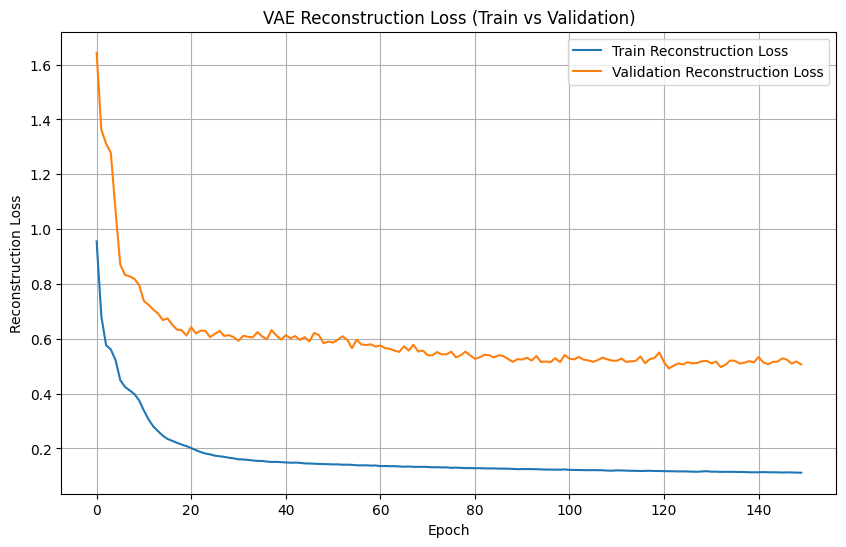

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(train_recon_losses, label='Train Reconstruction Loss')
plt.plot(val_recon_losses, label='Validation Reconstruction Loss')
plt.title('VAE Reconstruction Loss (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True)
plt.show()

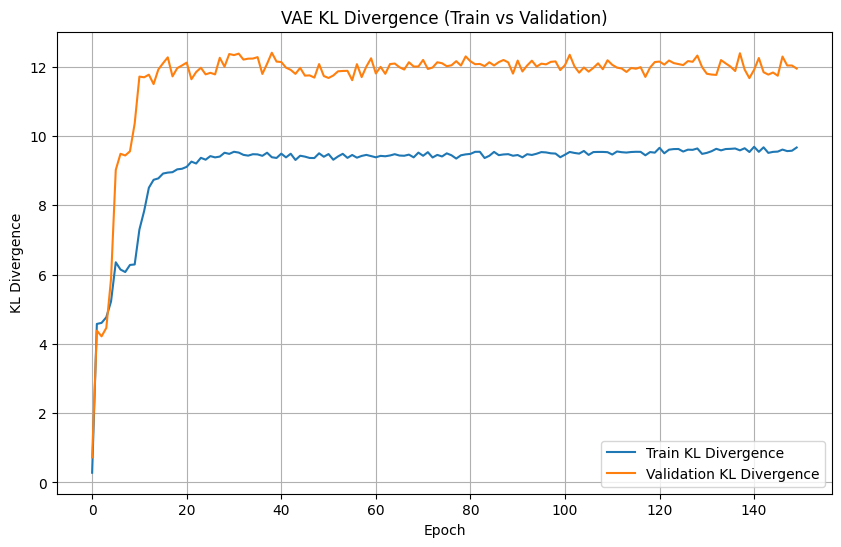

In [21]:
plt.figure(figsize=(10, 6))
plt.plot(train_kl_losses, label='Train KL Divergence')
plt.plot(val_kl_losses, label='Validation KL Divergence')
plt.title('VAE KL Divergence (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
comparison = pd.DataFrame({
    "train_mean": X_train_scaled.mean(axis=0),
    "val_mean": X_val_scaled.mean(axis=0),

    "train_std": X_train_scaled.std(axis=0),
    "val_std": X_val_scaled.std(axis=0),
}, index=X_train.columns)

comparison["mean_shift"] = (
    comparison["val_mean"]
    - comparison["train_mean"]
).abs()

comparison.sort_values(
    "mean_shift",
    ascending=False
).head(15)

,train_mean,val_mean,train_std,val_std,mean_shift
ram_mean,-4.065689e-16,2.950052,1.000000,2.096295,2.950052
new_remote_host_count,7.623167e-16,-1.504451,1.000000,0.985903,1.504451
net_sent_packets,1.276881e-15,-1.158853,1.000000,0.650591,1.158853
private_connection_count_mean,9.900876e-02,-0.965717,0.602589,0.033660,1.064726
new_connection_count,-9.528959e-17,-0.985287,1.000000,0.687649,0.985287
established_count_mean,2.286950e-16,-0.978314,1.000000,0.981577,0.978314
udp_endpoint_count_mean,3.303373e-15,-0.935908,1.000000,0.648179,0.935908
unique_remote_host_count,9.910118e-16,-0.899027,1.000000,1.095317,0.899027
tcp_connection_count_mean,1.270528e-17,-0.887577,1.000000,0.631154,0.887577
public_connection_count_mean,-8.258431e-17,0.829791,1.000000,1.935213,0.829791


# **B varinant**

In [23]:
Xb_train_tensor = torch.tensor(
    X_train_scaled_df.to_numpy(),
    dtype=torch.float32
)

Xb_val_tensor = torch.tensor(
    X_val_scaled_df.to_numpy(),
    dtype=torch.float32
)

Xb_test_tensor = torch.tensor(
    X_test_scaled_df.to_numpy(),
    dtype=torch.float32
)

In [24]:
B_train_loader = DataLoader(
    TensorDataset(Xb_train_tensor),
    batch_size=64,
    shuffle=True
)

B_val_loader = DataLoader(
    TensorDataset(Xb_val_tensor),
    batch_size=64,
    shuffle=False
)

In [25]:
vae_model_B = VariationalAE(input_dim=28, hidden_dim=56, latent_dim=6).to(device)
optimizer_B = torch.optim.Adam(vae_model_B.parameters(), lr=1e-3)

train_total_losses, val_total_losses, train_recon_losses, val_recon_losses, train_kl_losses, val_kl_losses = train(
    vae_model_B,
    B_train_loader,
    B_val_loader,
    optimizer_B,
    elbo_loss,
    device,
    epochs
)

Training on cuda
Epoch 1/150
Train Loss: 1.0055 (Recon: 1.0049, KL: 0.1106)
Val Loss:   1.7665 (Recon: 1.7654, KL: 0.1989)
Epoch 2/150
Train Loss: 0.8401 (Recon: 0.8222, KL: 2.9883)
Val Loss:   1.4159 (Recon: 1.3768, KL: 6.5122)
Epoch 3/150
Train Loss: 0.6489 (Recon: 0.6161, KL: 5.4551)
Val Loss:   1.3589 (Recon: 1.3211, KL: 6.2844)
Epoch 4/150
Train Loss: 0.6258 (Recon: 0.5945, KL: 5.2193)
Val Loss:   1.3698 (Recon: 1.3333, KL: 6.0876)
Epoch 5/150
Train Loss: 0.5856 (Recon: 0.5518, KL: 5.6348)
Val Loss:   1.1719 (Recon: 1.1277, KL: 7.3725)
Epoch 6/150
Train Loss: 0.5227 (Recon: 0.4820, KL: 6.7866)
Val Loss:   1.0280 (Recon: 0.9599, KL: 11.3518)
Epoch 7/150
Train Loss: 0.4672 (Recon: 0.4197, KL: 7.9275)
Val Loss:   0.9192 (Recon: 0.8377, KL: 13.5848)
Epoch 8/150
Train Loss: 0.4276 (Recon: 0.3755, KL: 8.6746)
Val Loss:   0.8907 (Recon: 0.8134, KL: 12.8910)
Epoch 9/150
Train Loss: 0.4037 (Recon: 0.3515, KL: 8.6933)
Val Loss:   0.8941 (Recon: 0.8177, KL: 12.7206)
Epoch 10/150
Train Loss: 

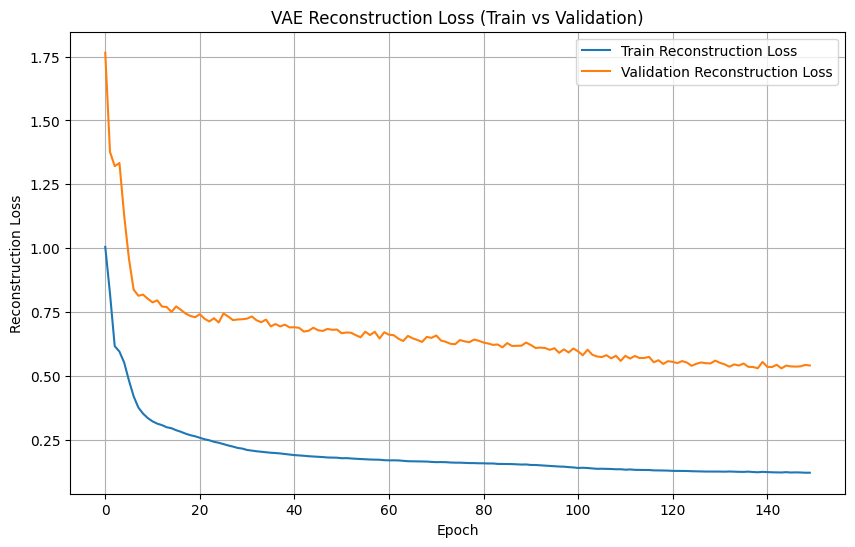

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(train_recon_losses, label='Train Reconstruction Loss')
plt.plot(val_recon_losses, label='Validation Reconstruction Loss')
plt.title('VAE Reconstruction Loss (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.legend()
plt.grid(True)
plt.show()

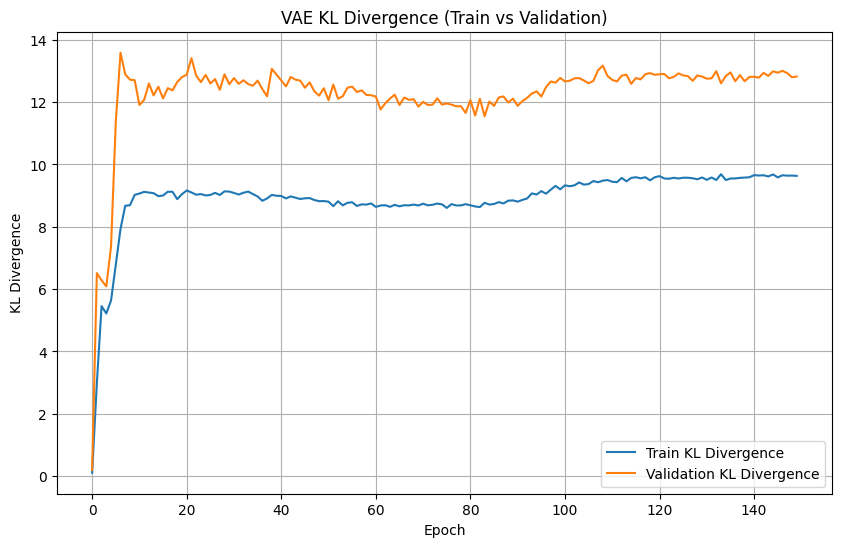

In [27]:
plt.figure(figsize=(10, 6))
plt.plot(train_kl_losses, label='Train KL Divergence')
plt.plot(val_kl_losses, label='Validation KL Divergence')
plt.title('VAE KL Divergence (Train vs Validation)')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


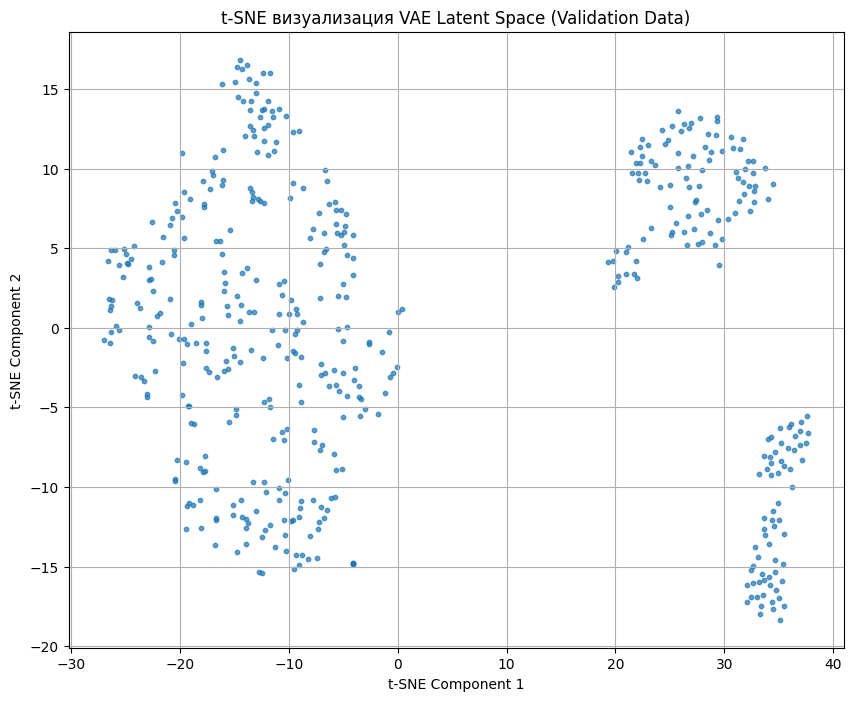

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

vae_model_B.eval()

latent_vectors = []
with torch.no_grad():
    for data in B_val_loader:
        inputs = data[0].to(device)
        mu, log_var = vae_model_B.encode(inputs)
        latent_vectors.append(mu.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors, axis=0)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
latent_tsne = tsne.fit_transform(latent_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1], s=10, alpha=0.7)
plt.title('t-SNE визуализация VAE Latent Space (Validation Data)')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.grid(True)
plt.show()

В латентном пространстве наблюдаются несколько устойчиво различающихся режимов поведения

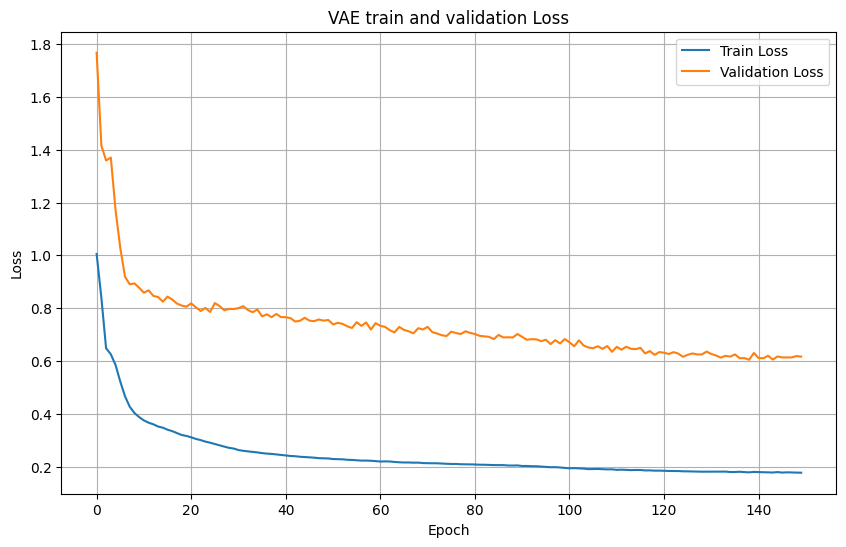

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(train_total_losses, label='Train Loss')
plt.plot(val_total_losses, label='Validation Loss')
plt.title('VAE train and validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Threshold

In [35]:
vae_model_B.eval()

with torch.no_grad():
    mu, log_var = vae_model_B.encode(Xb_val_tensor.to(device))
    reconstruction = vae_model_B.decode(mu)

    anomaly_scores = (
        (Xb_val_tensor.to(device) - reconstruction) ** 2
    ).mean(dim=1)

anomaly_scores = anomaly_scores.cpu().numpy()

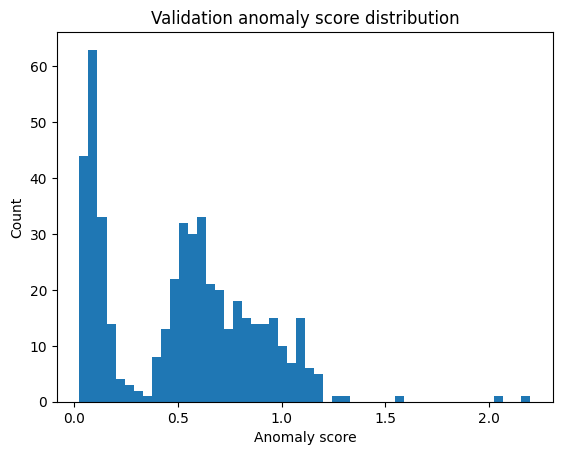

In [36]:
plt.hist(anomaly_scores, bins=50)
plt.xlabel("Anomaly score")
plt.ylabel("Count")
plt.title("Validation anomaly score distribution")
plt.show()

In [37]:
for q in [90, 95, 97, 99, 99.5, 99.9]:
    print(
        q,
        np.percentile(anomaly_scores, q)
    )

90 0.97819084
95 1.0832022
97 1.1287457
99 1.2031697
99.5 1.4486344
99.9 2.1224356


In [38]:
threshold = round(np.percentile(
    anomaly_scores,
    99.5
), 3)

threshold

np.float32(1.449)

In [39]:
import json

with open("threshold.json", "w") as f:
    json.dump({
        "threshold": float(threshold),
        "percentile": 99.5
    }, f, indent=2)

In [40]:
n_anomalies = (anomaly_scores > float(threshold)).sum()
share = (anomaly_scores > float(threshold)).mean()

print(n_anomalies)
print(share)

3
0.00625


In [41]:
bundle = {
    "model_state_dict": vae_model_B.state_dict(),

    "input_dim": 28,
    "hidden_dim": 56,
    "latent_dim": 6,
    "beta": 0.006,

    "threshold": float(threshold),

    "feature_names": X_train_to_scale.columns.tolist(),
    "log_columns": LOG_COLUMNS,

    "scaler_mean": torch.tensor(
        scaler.mean_,
        dtype=torch.float32
    ),

    "scaler_scale": torch.tensor(
        scaler.scale_,
        dtype=torch.float32
    ),
}

torch.save(bundle, "ueba_bundle.pt")

print("Threshold:", bundle["threshold"])
print("Features:", len(bundle["feature_names"]))
print(bundle["feature_names"])

Threshold: 1.4490000009536743
Features: 28
['cpu_mean', 'cpu_max', 'ram_mean', 'ram_max', 'swap_mean', 'process_count_mean', 'new_process_count', 'disk_read_bytes', 'disk_write_bytes', 'disk_read_ops', 'disk_write_ops', 'net_sent_bytes', 'net_recv_bytes', 'net_sent_packets', 'net_recv_packets', 'tcp_connection_count_mean', 'udp_endpoint_count_mean', 'established_count_mean', 'listening_count_mean', 'time_wait_count_mean', 'new_connection_count', 'closed_connection_count', 'unique_remote_host_count', 'new_remote_host_count', 'unique_remote_port_count', 'public_connection_count_mean', 'private_connection_count_mean', 'outbound_inbound_ratio']
